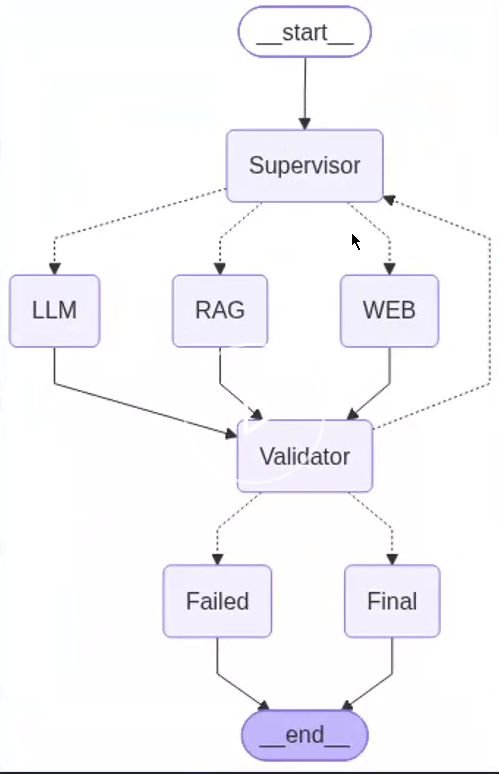

In [1]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY environment variable is not set. Please set it in your .env file.")

In [4]:
model="openai/gpt-oss-20b"
llm=ChatGroq(model=model, temperature=0.6,reasoning_format="hidden")

In [5]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

In [6]:
def call_model(state: MessagesState):
    messages = state["messages"]

    print("current messages:", messages)

    response = llm.invoke(messages)

    print("model content:", response.content)

    return {
        "messages": [response]
    }
builder=StateGraph(MessagesState)
builder.add_node("mybot", call_model)
builder.add_edge(START, "mybot")
builder.add_edge("mybot", END)
app=builder.compile()

In [7]:
input={"messages":[HumanMessage("Hello, how are you?")]}
result=app.invoke(input)

current messages: [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='8879d2a7-e75d-4edd-85e0-32eb4b089c19')]
model content: Hi there! I’m doing great—thanks for asking. How about you? Anything interesting going on today?


ADVANCE WORKFLOW

In [8]:
from typing_extensions import TypedDict,NotRequired
from langchain_core.messages import AIMessage
class State(TypedDict):
    question:str
    answer:NotRequired[str]
    response:NotRequired[AIMessage]
    input_tokens:NotRequired[int]
    output_tokens:NotRequired[int]
    total_tokens:NotRequired[int]

In [9]:
def llm_node(state:State):
     messages=state["question"]
     response=llm.invoke(messages)
     print(f"generated response: {response.content}")
     return{"answer": response.content,"response": response}

In [10]:
def token_counter_node(state:State):
    print("-----token_counter_node-----")
    response=state["response"]
    usage=response.usage_metadata or {}
    input_tokens=usage.get("input_tokens")
    output_tokens=usage.get("output_tokens")
    total_tokens=usage.get("total_tokens")
    print(f"Input tokens: {input_tokens}, Output tokens: {output_tokens}, Total tokens: {total_tokens}")
    return {"input_tokens": input_tokens, "output_tokens": output_tokens, "total_tokens": total_tokens}

In [11]:
workflow=StateGraph(State)
workflow.add_node("llm_node", llm_node)
workflow.add_node("token_counter_node", token_counter_node)
workflow.add_edge(START, "llm_node")
workflow.add_edge("llm_node", "token_counter_node")
workflow.add_edge("token_counter_node", END)

In [12]:
app=workflow.compile()

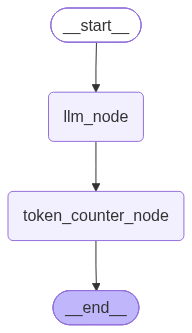

In [13]:
from IPython.display import Image, display
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [14]:
result=app.invoke({"question":"tell me about tata group in detail ?"})

generated response: ## Tata Group – A Comprehensive Overview

| Item | Details |
|------|---------|
| **Founded** | 1839 (as a trading company) |
| **Founder** | Jamsetji Tata |
| **Headquarters** | Mumbai, India |
| **Core Values** | Integrity, Leadership, Accountability, Excellence, Respect |
| **Revenue (FY 2023‑24)** | ~₹7.5 trillion (≈US$95 billion) – across all Tata enterprises |
| **Employees** | ~350,000+ worldwide |
| **Global Presence** | Operations in 100+ countries; 30+ subsidiaries in 12 core sectors |
| **Key Pillars** | Automotive, IT, Steel, Power, Consumer & Retail, Chemicals, Telecom, Aerospace, Financial Services, Hospitality, Media & Entertainment |

> **Note:** Tata Group is a *conglomerate* of independent companies that share a common brand, ethos, and governance structure. The Tata Group’s “Tata” brand is protected by a *Tata Group Brand Management* umbrella.

---

## 1. Historical Trajectory

| Era | Milestones |
|-----|------------|
| **1839‑1900** | Jamsetji T

TOO ADVANCE WORKFLOW

In [15]:
import os
import json
from typing_extensions import TypedDict,NotRequired
from pydantic import BaseModel, Field
from langchain_core.messages import AIMessage,HumanMessage
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import(TextLoader,DirectoryLoader)
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch

d:\AGENTIC-AI\agentic-ai-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\vansh_hxqeh4o\AppData\Local\Temp\ipykernel_16880\1010126476.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import(TextLoader,DirectoryLoader)


In [16]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)

In [17]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2089.64it/s]


In [18]:
embedding_vector = embeddings.embed_query("Hello")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [19]:
loader = DirectoryLoader(
    r"D:\AGENTIC-AI\Langraph-intro\data",
    glob="**/*.txt",
    loader_cls=TextLoader
)
docs = loader.load()
print(f"Loaded {len(docs)} documents.")

Loaded 1 documents.


In [20]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
)
text_chunks = text_splitter.split_documents(docs)
print(f"Split into {len(text_chunks)} chunks.")

Split into 13 chunks.


In [21]:
vectorstore = Chroma(
    collection_name="usa_economy",
    embedding_function=embeddings,
)

In [22]:
vectorstore.add_documents(documents=text_chunks)
print("Documents added to vectorstore.")

Documents added to vectorstore.


In [23]:
reteriever=vectorstore.as_retriever(search_kwargs={"k": 3})

In [24]:
test_query = "What is the current state of the US economy?"
retrieved_docs = reteriever.invoke(test_query)
print(f"Retrieved {len(retrieved_docs)} documents for the query: '{test_query}'")

Retrieved 3 documents for the query: 'What is the current state of the US economy?'


In [25]:
from langchain_tavily import TavilySearch
import os
from dotenv import load_dotenv
load_dotenv()
web_search = TavilySearch(max_results=3,search_depth="advanced",topic="general")

In [26]:
result=web_search.invoke("What is the current state of the US economy?")
print(result)

{'query': 'What is the current state of the US economy?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://lsa.umich.edu/content/dam/econ-assets/Econdocs/RSQE%20PDFs/RSQE_May26_US_Forecast.pdf', 'title': 'United States Economic Outlook', 'content': 'United States Economic Outlook 2026–2028 May 2026 University of Michigan, Ann Arbor Department of Economics 611 Tappan Avenue Ann Arbor, MI 48109-1120 lsa.umich.edu/econ/rsqe 734-764-2567 For Release: 05/18/2026 "The Michigan Model" Gabriel M. Ehrlich, Director George A. Fulton & Saul H. Hymans Directors Emeriti The U.S. Economic Outlook for 2026–2028 Alexander Boca, Jacob T. Burton, Gabriel M. Ehrlich, Daniil Manaenkov, and Yinuo Zhang University of Michigan Executive Summary AI Boom Bolsters the U.S. Economy The U.S. economy continued to expand in the first quarter of 2026, with headline real GDP growing at an annualized rate of 2.0 percent. Growth was bolstered by the reopening of the federal govern

## PYDANTIC BASED MODEL

In [28]:
from typing import Literal
from pydantic import BaseModel, Field

class RouteDecision(BaseModel):
    route: Literal["RAG", "LLM", "WEB"] = Field(
        description="node that should handle the user query"
    )
    reasoning: str = Field(
        description="reason for choosing this route"
    )

In [29]:
supervisor_model=llm.with_structured_output(schema=RouteDecision.model_json_schema(),method="json_schema")

In [30]:
supervisor_model.invoke("hi")

{'route': 'LLM', 'reasoning': 'User greeted, no need for external resources.'}

In [31]:
class validation_result(BaseModel):
    passed:bool = Field(
        description="true if the  generated answer passes validation"
    )
    score:int = Field(
        ge=0,le=10,description="quality score from 0 to 10"
    )
    feedback: str = Field(
        description="reason for validation result"
    )
validation_model=llm.with_structured_output(schema=validation_result.model_json_schema(),method="json_schema")